## 📊 Consumer Price Index (CPI) Dataset Description

This dataset contains the **annual Consumer Price Index (CPI) for Malaysia**, which measures the average change over time in the prices of goods and services consumed by households. CPI is commonly used as an indicator of **inflation and cost of living**. The data is published by the Department of Statistics Malaysia (DOSM) and accessed through the OpenDOSM data portal.

In this dataset, each observation represents the CPI value for a specific year and category.

### 🧾 Variables Description

| Column     | Description                                                                                                                                                  |
| ---------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `date`     | The year of observation. CPI is reported annually.                                                                                                           |
| `division` | The CPI category (also known as the main group or division of goods and services).                                                                           |
| `index`    | CPI value with **base year 2010 = 100**. Values below 100 indicate lower price levels compared to 2010, while values above 100 indicate higher price levels. |

---

## 📦 CPI Divisions (The 13 Main Groups)

The CPI categories in this dataset follow the international **Classification of Individual Consumption by Purpose (COICOP)** standard. Malaysia groups consumer expenditures into **13 main divisions**, which represent different types of household consumption:

1. **Food and Non-Alcoholic Beverages**
2. **Alcoholic Beverages and Tobacco**
3. **Clothing and Footwear**
4. **Housing, Water, Electricity, Gas and Other Fuels**
5. **Furnishings, Household Equipment and Routine Household Maintenance**
6. **Health**
7. **Transport**
8. **Communication**
9. **Recreation Services and Culture**
10. **Education**
11. **Restaurants and Hotels**
12. **Insurance and Financial Services**
13. **Miscellaneous Goods and Services**

These divisions allow researchers to analyse inflation trends across different sectors of the economy. For example, in the context of the **EduNilai project**, the **Education**, **Housing**, **Food**, and **Transport** divisions are particularly important, as they reflect the major living and study costs faced by Malaysian students.

---

## 🎯 Importance for This Study

This CPI dataset will be used to:

* Adjust tuition fees and salary data for inflation.
* Analyse trends in education and living costs in Malaysia.
* Estimate the **real return on investment (ROI) of university degrees**.
* Provide a more realistic comparison of costs over time.

---

## 📚 Data Source

* **Primary Source:** Department of Statistics Malaysia (DOSM)
* **Link:** https://open.dosm.gov.my/data-catalogue/cpi_annual


In [2]:
# If not already installed, do: pip install pandas fastparquet
import pandas as pd

URL_DATA = 'https://storage.dosm.gov.my/cpi/cpi_2d_annual.parquet'

df = pd.read_parquet(URL_DATA)
if 'date' in df.columns: df['date'] = pd.to_datetime(df['date'])

df

,date,division,index
0,1960-01-01,overall,21.309241
1,1961-01-01,overall,21.270798
2,1962-01-01,overall,21.293864
3,1963-01-01,overall,21.955092
4,1964-01-01,overall,21.866672
...,...,...,...
554,2021-01-01,13,116.558333
555,2022-01-01,13,118.866667
556,2023-01-01,13,121.808333
557,2024-01-01,13,125.466667


In [3]:
# Filter from 2010 onward
df_2010 = df[df['date'].dt.year >= 2010]

# Pivot table
pivot_cpi = df_2010.pivot(index='date', columns='division', values='index')

pivot_cpi

division,01,02,03,04,05,06,07,08,09,10,11,12,13,overall
date,,,,,,,,,,,,,,
2010-01-01,99.991667,100.000000,100.008333,100.008333,99.941667,100.016667,100.016667,100.008333,99.983333,100.000000,100.000000,99.983333,100.016667,100.016667
2011-01-01,104.800000,104.608333,99.758333,101.775000,101.758333,102.733333,104.416667,99.725000,101.966667,102.233333,105.866667,100.141667,102.416667,103.200000
2012-01-01,107.616667,105.025000,99.191667,103.391667,103.783333,104.816667,105.141667,99.083333,103.175000,104.683333,109.008333,101.400000,104.400000,104.908333
2013-01-01,111.450000,111.283333,98.616667,105.233333,105.425000,106.816667,107.241667,98.416667,103.266667,107.225000,111.666667,102.991667,104.716667,107.116667
2014-01-01,115.175000,124.216667,98.425000,108.800000,106.533333,109.883333,112.400000,97.725000,104.933333,109.750000,116.850000,104.483333,105.350000,110.483333
2015-01-01,119.358333,141.000000,98.908333,111.450000,109.383333,114.750000,107.316667,99.633333,106.725000,112.400000,121.741667,108.766667,109.725000,112.808333
2016-01-01,123.908333,165.241667,98.525000,114.175000,111.958333,117.900000,102.433333,98.050000,109.433333,114.825000,125.108333,111.250000,112.875000,115.150000
2017-01-01,128.800000,165.491667,98.175000,116.708333,114.400000,120.916667,115.925000,97.725000,111.508333,116.708333,128.241667,111.600000,114.191667,119.525000
2018-01-01,130.900000,165.308333,96.166667,119.025000,114.833333,121.883333,117.675000,96.016667,111.008333,118.033333,130.183333,110.283333,112.575000,120.683333


<Figure size 1200x600 with 0 Axes>

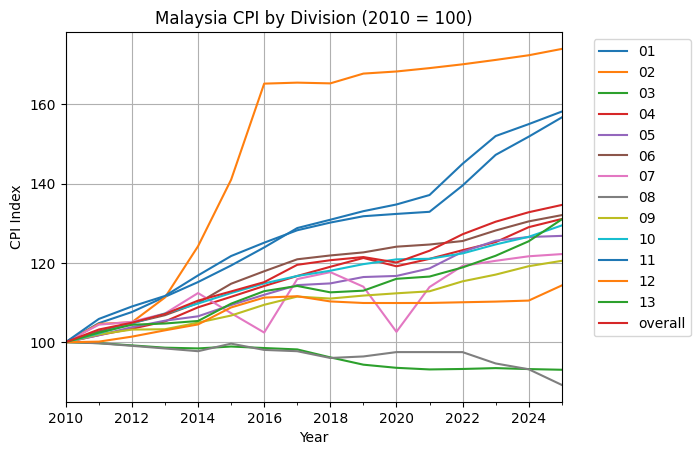

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

pivot_cpi.plot()
plt.title("Malaysia CPI by Division (2010 = 100)")
plt.xlabel("Year")
plt.ylabel("CPI Index")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [6]:
# check df_2010 before exporting to csv
df_2010

,date,division,index
50,2010-01-01,overall,100.016667
51,2011-01-01,overall,103.200000
52,2012-01-01,overall,104.908333
53,2013-01-01,overall,107.116667
54,2014-01-01,overall,110.483333
...,...,...,...
554,2021-01-01,13,116.558333
555,2022-01-01,13,118.866667
556,2023-01-01,13,121.808333
557,2024-01-01,13,125.466667


In [5]:
import os

os.makedirs('../data/inflation', exist_ok=True)
df_2010.to_csv('../data/inflation/cpi_2010_onwards.csv', index=False, encoding='utf-8')
print("Saved -> ../data/inflation/cpi_2010_onwards.csv")
print(f"Rows: {len(df_2010)}")

Saved -> ../data/inflation/cpi_2010_onwards.csv
Rows: 224
